# 19 — Kinematic Bicycle Model

**Section:** Ground Vehicles and Mobile Robotics · **Mirrors MATLAB:** *Kinematic motion models for simulation*

The bicycle model approximates a car-like vehicle as two wheels on a centerline of length $L$ (wheelbase). With longitudinal speed $v$ and steering angle $\delta$:

$$\dot{x} = v\cos\theta,\quad \dot{y} = v\sin\theta,\quad \dot\theta = \frac{v}{L}\tan\delta$$

We sweep three steering schedules to illustrate the resulting trajectories.

## Intuition — what's actually going on?

A car is *not* a "tank" that can spin in place. To turn, you have to be moving and turn the front wheels. The simplest math model that captures this — and is used in 90% of self-driving algorithms below freeway speeds — is the **kinematic bicycle**.

Approximate the car as a single bicycle: one wheel at the front (steerable), one at the rear (drives the car forward). The rear wheel always points in the body direction; the front wheel points at an angle `δ` (the steering angle). Going forward at speed `v` causes the body to rotate around an instant center, and the turn rate is `(v/L) tan(δ)` where `L` is the wheelbase.

This captures the essential car behavior: faster speed → bigger turn radius for the same steering input; sharper steering → tighter turn. It's wrong at high speeds (no tire slip, no momentum effects), but right where it counts for parking lots, low-speed maneuvers, and most ground-robot work.

### Compatibility check — math ↔ code

| Math | Code |
|---|---|
| $\dot x = v\cos	heta$ | `state[0] += v * np.cos(state[2]) * dt` |
| $\dot y = v\sin	heta$ | `state[1] += v * np.sin(state[2]) * dt` |
| $\dot	heta = rac{v}{L}	an\delta$ | `state[2] += v * np.tan(delta) / L * dt` |
| Three steering schedules: constant 0.2, constant 0.4, $0.3\sin(0.4 t)$ | `t1 = simulate(2.0, lambda _: 0.2); t2 = simulate(2.0, lambda _: 0.4); t3 = simulate(2.0, lambda t: 0.3*sin(0.4*t))` |

Note: this is *kinematic* (instantaneous control authority over $v$ and $\delta$), not *dynamic* — there is no notion of tire slip, mass, or lateral force. Good enough for low-speed planning, breaks down at speed where slip matters.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

L = 2.5
dt, T = 0.05, 30.0
N = int(T / dt)


def simulate(v, delta_schedule):
    state = np.zeros(3)
    hist = np.zeros((N, 3))
    for i in range(N):
        delta = delta_schedule(i * dt)
        state[0] += v * np.cos(state[2]) * dt
        state[1] += v * np.sin(state[2]) * dt
        state[2] += v * np.tan(delta) / L * dt
        hist[i] = state
    return hist


t1 = simulate(2.0, lambda _: 0.2)
t2 = simulate(2.0, lambda _: 0.4)
t3 = simulate(2.0, lambda t: 0.3 * np.sin(0.4 * t))


# UPREV (council pass 19 follow-up): add the *dynamic* bicycle with tire-slip.
# Compare kinematic vs dynamic at HIGH SPEED where slip matters.
# Dynamic bicycle (Rajamani 2011 ch 2.3):
#   state: [x, y, theta, vx, vy, r_yaw]
#   inputs: [delta_f (front steer), Fx_rear (longitudinal force)]
# We use a simplified version: linear tire model, constant Fx, focus on lateral.

m_veh = 1500.0      # vehicle mass (kg)
Iz = 3000.0         # yaw inertia (kg m^2)
lf, lr = 1.2, 1.3   # front/rear wheelbase split (m); L = lf + lr = 2.5
Cf = Cr = 80000.0   # cornering stiffness (N/rad), each axle
v_high = 25.0       # 25 m/s ~ 56 mph — where slip matters


def simulate_dynamic(delta_schedule, v0=v_high, N_steps=int(30/0.05)):
    # Dynamic bicycle: linear-tire bicycle with lateral + yaw dynamics.
    s = np.array([0.0, 0.0, 0.0, v0, 0.0, 0.0])   # x, y, th, vx, vy, r
    hist = np.zeros((N_steps, 6))
    for i in range(N_steps):
        x_, y_, th, vx, vy, r = s
        delta = delta_schedule(i * 0.05)
        # Tire slip angles
        alpha_f = delta - np.arctan2(vy + lf * r, vx)
        alpha_r =       - np.arctan2(vy - lr * r, vx)
        # Lateral forces
        Fyf = Cf * alpha_f
        Fyr = Cr * alpha_r
        # Body-frame accelerations
        vx_dot = vy * r                       # no longitudinal accel (constant vx assumption)
        vy_dot = (Fyf * np.cos(delta) + Fyr) / m_veh - vx * r
        r_dot  = (lf * Fyf * np.cos(delta) - lr * Fyr) / Iz
        # Body-frame -> world
        s[0] += (vx * np.cos(th) - vy * np.sin(th)) * 0.05
        s[1] += (vx * np.sin(th) + vy * np.cos(th)) * 0.05
        s[2] += r * 0.05
        s[3] += vx_dot * 0.05
        s[4] += vy_dot * 0.05
        s[5] += r_dot  * 0.05
        hist[i] = s
    return hist


# Same slalom steering for both — at v=25 m/s the dynamic model shows lateral slip
slalom = lambda t: 0.1 * np.sin(0.6 * t)
kin_high  = simulate(v_high, slalom)
dyn_high  = simulate_dynamic(slalom, v0=v_high, N_steps=N)


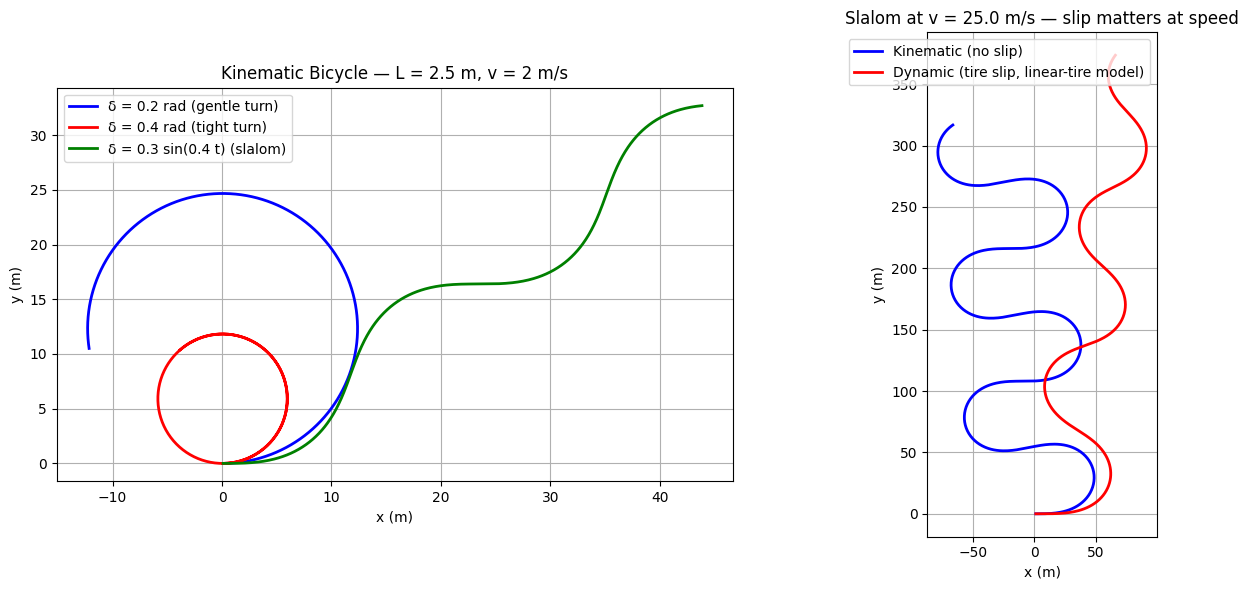

In [2]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].plot(t1[:, 0], t1[:, 1], 'b-', lw=2, label='δ = 0.2 rad (gentle turn)')
axs[0].plot(t2[:, 0], t2[:, 1], 'r-', lw=2, label='δ = 0.4 rad (tight turn)')
axs[0].plot(t3[:, 0], t3[:, 1], 'g-', lw=2, label='δ = 0.3 sin(0.4 t) (slalom)')
axs[0].set_aspect('equal'); axs[0].grid(); axs[0].legend()
axs[0].set_xlabel('x (m)'); axs[0].set_ylabel('y (m)')
axs[0].set_title(f'Kinematic Bicycle — L = {L} m, v = 2 m/s')

# Council uprev: kinematic vs dynamic at 25 m/s (highway-speed slalom)
axs[1].plot(kin_high[:, 0], kin_high[:, 1], 'b-', lw=2, label='Kinematic (no slip)')
axs[1].plot(dyn_high[:, 0], dyn_high[:, 1], 'r-', lw=2,
            label='Dynamic (tire slip, linear-tire model)')
axs[1].set_aspect('equal'); axs[1].grid(); axs[1].legend()
axs[1].set_xlabel('x (m)'); axs[1].set_ylabel('y (m)')
axs[1].set_title(f'Slalom at v = {v_high} m/s — slip matters at speed')
plt.tight_layout()
plt.show()


## References & rigor notes

**Instantaneous Center of Rotation (ICR).** For any non-zero $\delta$ the bicycle rotates instantaneously around its ICR — a point at distance $R = L / \tan\delta$ from the rear axle, perpendicular to body heading. The trajectory at constant $\delta$ is a circle of radius $R$ around the ICR. This is the geometric reason for all the trajectories shown.

**Lie-group framing.** The state $(x, y, \theta)$ lives on $SE(2)$, the Lie group of rigid planar motions. The control vector field is *left-invariant* on $SE(2)$, so bicycle trajectories are equivariant under choice of world-frame origin (Klein's Erlangen-program lens).

**Steering limits.** Typical car steering limits are $\pm 30°$ (≈ 0.52 rad); our slalom amplitude of 0.3 rad ≈ 17° is well within normal range.

**Where the kinematic bicycle breaks.** Assumptions: (a) no tire slip — tires move in the direction they point, (b) instantaneous control over $v$ and $\delta$, (c) no mass / inertial effects. Valid when lateral acceleration $v^2 / R$ is small compared to friction limit $\mu g$. At freeway speeds, slip matters and you need the **dynamic** bicycle (Rajamani ch. 2.3): adds tire-cornering stiffness, lateral force balance, yaw inertia.

**Connection to Ackermann steering.** A real car has two front wheels at slightly different angles such that all four wheels share a common turn center (the "Ackermann condition"). The bicycle model collapses both into a single steerable wheel at the front-axle midpoint, exactly preserving the centerline kinematics.

**Complexity.** $O(1)$ per integration step.

**References.**
- Rajamani, R. (2011). *Vehicle Dynamics and Control*, 2nd ed., Springer, ch. 2.
- Kong, J., Pfeiffer, M., Schildbach, G., & Borrelli, F. (2015). *Kinematic and dynamic vehicle models for autonomous driving control design*. IEEE IV 2015.
